# Task 3: Heart Disease Prediction

**Objective:** Build a classifier to predict whether a patient is at risk of heart disease based on clinical features.

**Dataset:** Heart Disease UCI Dataset — 303 patients, 13 features, binary target (0 = no disease, 1 = disease).

**What I'll do:**
- EDA + data cleaning
- Train Logistic Regression and Decision Tree
- Evaluate with accuracy, ROC-AUC, confusion matrix
- Identify most influential features


In [1]:
!pip install scikit-learn matplotlib seaborn pandas --quiet

In [2]:
# --- imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_curve, roc_auc_score
)

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120

import warnings
warnings.filterwarnings('ignore')

## 1. Load the Dataset

We load directly from the UCI ML Repository — no Kaggle account needed.

In [3]:
# load from uci repository mirror — works without kaggle login
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'

col_names = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs',
    'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'
]

df = pd.read_csv(url, names=col_names, na_values='?')

# the original target has values 0-4; we convert to binary (0 = no disease, 1 = disease)
df['target'] = (df['target'] > 0).astype(int)

print(f'dataset shape: {df.shape}')
print(f'disease cases: {df["target"].sum()} | no disease: {(df["target"]==0).sum()}')
df.head()

dataset shape: (303, 14)
disease cases: 139 | no disease: 164


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## 2. Data Cleaning

In [4]:
# check for missing values
print('missing values per column:')
print(df.isnull().sum())

missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


In [5]:
# only 'ca' and 'thal' have a handful of NaNs — fill with median (safe for clinical data)
df['ca'].fillna(df['ca'].median(), inplace=True)
df['thal'].fillna(df['thal'].median(), inplace=True)

print('missing values after cleaning:', df.isnull().sum().sum())

missing values after cleaning: 0


## 3. Exploratory Data Analysis (EDA)

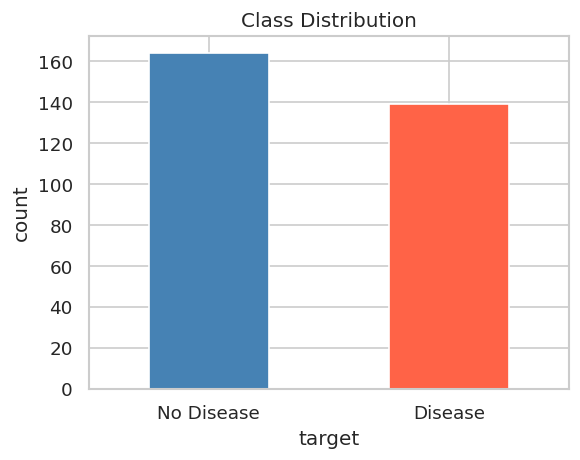

In [6]:
# target distribution
plt.figure(figsize=(5, 4))
df['target'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'], edgecolor='white')
plt.xticks([0, 1], ['No Disease', 'Disease'], rotation=0)
plt.title('Class Distribution')
plt.ylabel('count')
plt.tight_layout()
plt.show()

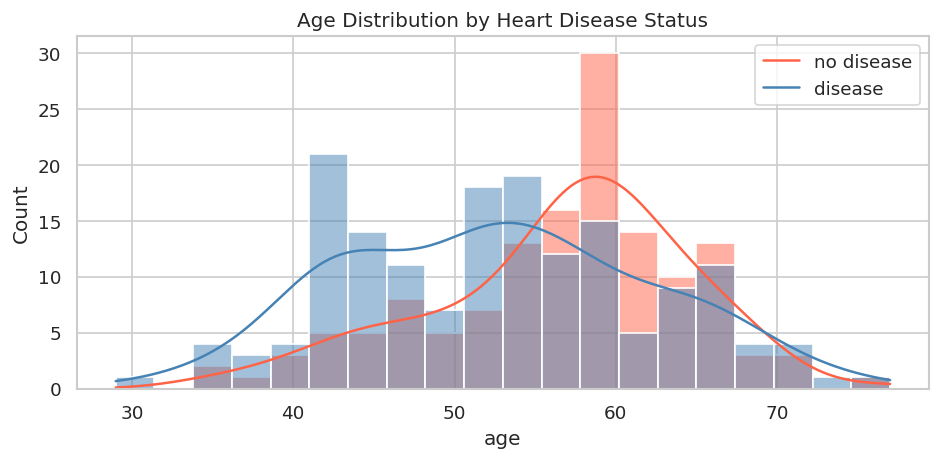

In [7]:
# age distribution by outcome — older patients tend to have higher risk
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='age', hue='target', bins=20, kde=True,
             palette={0: 'steelblue', 1: 'tomato'})
plt.title('Age Distribution by Heart Disease Status')
plt.xlabel('age')
plt.legend(labels=['no disease', 'disease'])
plt.tight_layout()
plt.show()

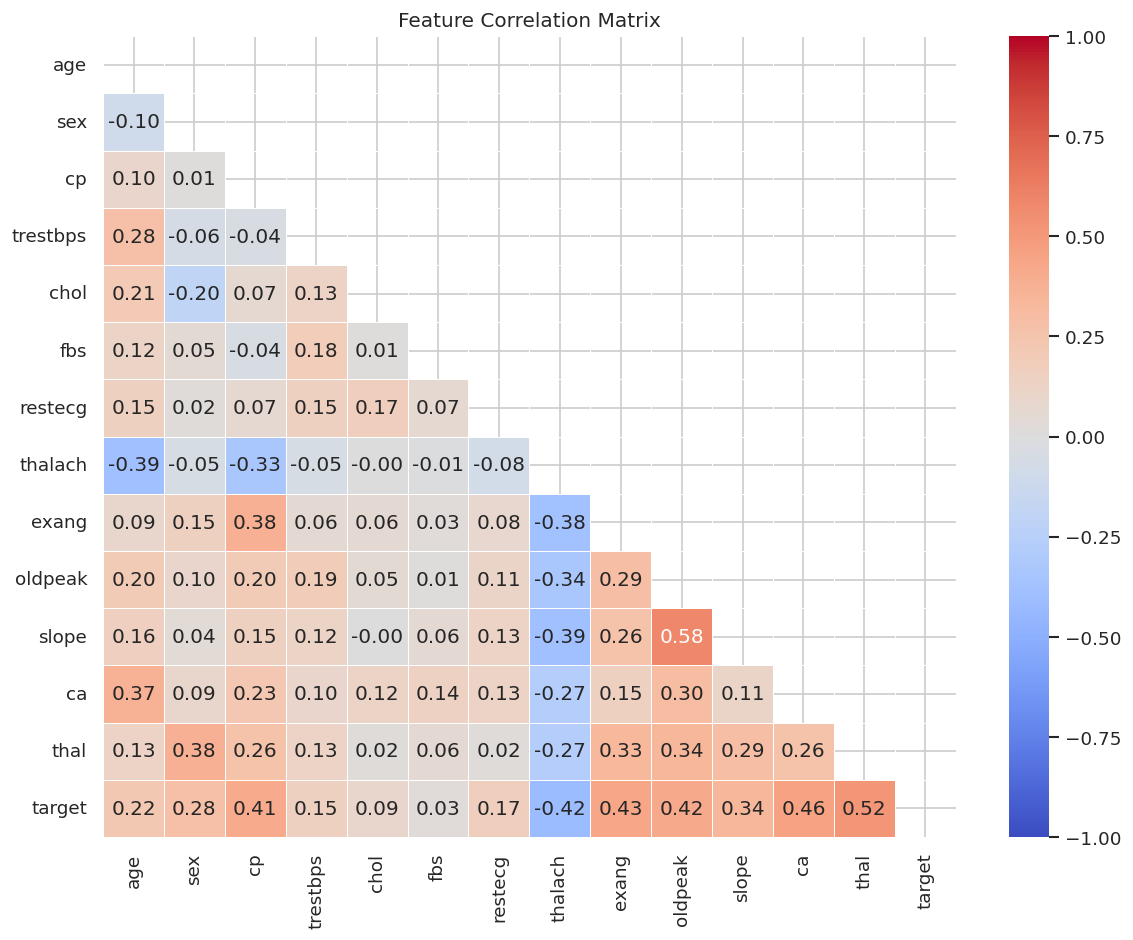

In [8]:
# correlation heatmap — what's linearly related to the target?
plt.figure(figsize=(10, 8))
corr = df.corr().round(2)
mask = np.triu(np.ones_like(corr, dtype=bool))  # only show lower triangle
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.5, fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

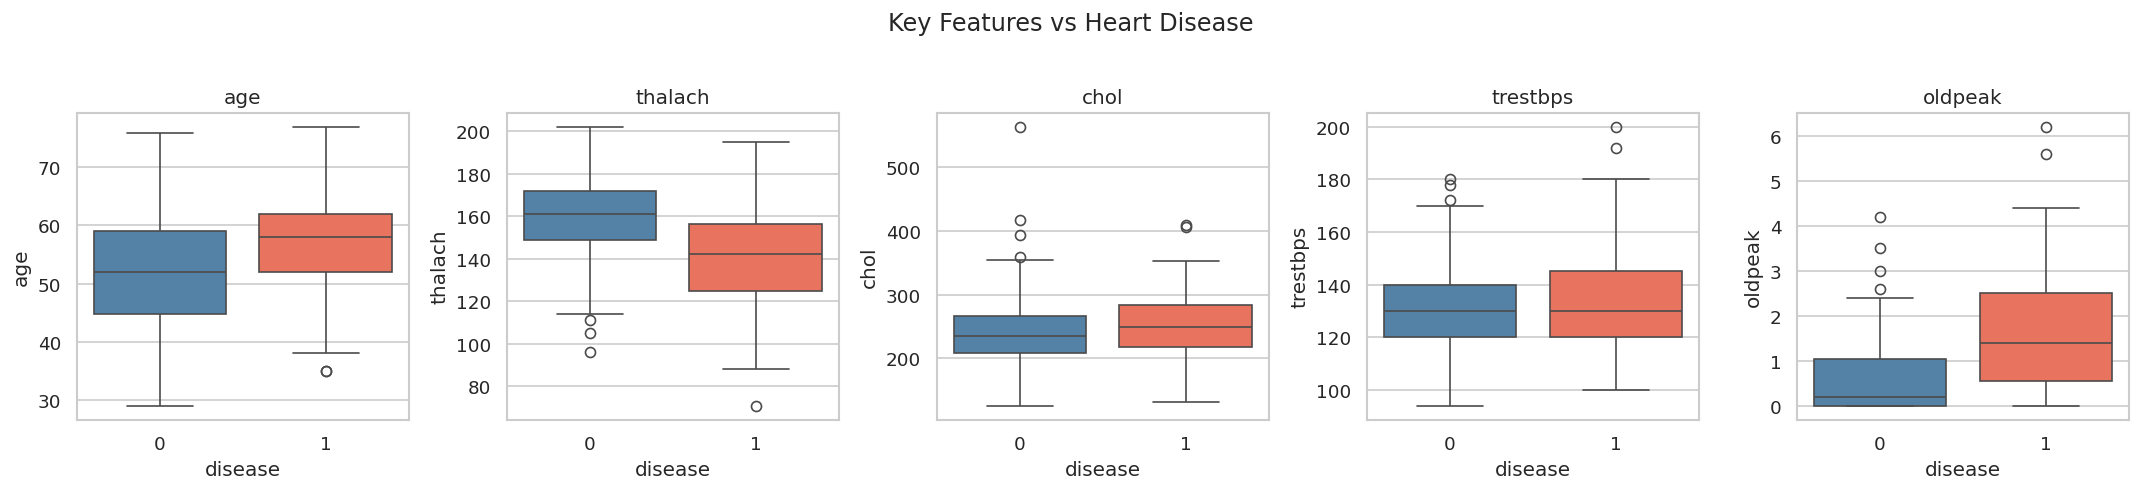

In [11]:
# quick look at key continuous features vs target
key_features = ['age', 'thalach', 'chol', 'trestbps', 'oldpeak']
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for ax, feat in zip(axes, key_features):
    sns.boxplot(data=df, x='target', y=feat, ax=ax,
                palette={'0': 'steelblue', '1': 'tomato'})
    ax.set_title(feat)
    ax.set_xlabel('disease')

plt.suptitle('Key Features vs Heart Disease', y=1.02)
plt.tight_layout()
plt.show()

## 4. Prepare Data for Modeling

In [12]:
X = df.drop('target', axis=1)
y = df['target']

# stratified split ensures both classes are proportionally represented in train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# scale features — logistic regression is sensitive to feature scale
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f'train: {X_train.shape[0]} | test: {X_test.shape[0]}')

train: 242 | test: 61


## 5. Train Models

In [13]:
# logistic regression — a strong baseline for binary classification
lr = LogisticRegression(max_iter=1000, random_state=42, solver='liblinear')
lr.fit(X_train_s, y_train)

# decision tree — interpretable, shows clear decision paths
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)  # trees don't need scaling

print('models trained!')

models trained!


## 6. Evaluate Models

In [14]:
def evaluate_classifier(name, model, X_test, y_test): # Removed 'scaled=True'
    """print accuracy, classification report, confusion matrix, and roc-auc"""
    preds = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, preds)
    auc = roc_auc_score(y_test, proba)

    print(f'\n=== {name} ===')
    print(f'accuracy: {acc:.3f}  |  ROC-AUC: {auc:.3f}')
    print(classification_report(y_test, preds, target_names=['no disease', 'disease']))

    return preds, proba

lr_preds, lr_proba = evaluate_classifier('Logistic Regression', lr, X_test_s, y_test)
dt_preds, dt_proba = evaluate_classifier('Decision Tree', dt, X_test, y_test)


=== Logistic Regression ===
accuracy: 0.869  |  ROC-AUC: 0.951
              precision    recall  f1-score   support

  no disease       0.93      0.82      0.87        33
     disease       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61


=== Decision Tree ===
accuracy: 0.787  |  ROC-AUC: 0.864
              precision    recall  f1-score   support

  no disease       0.83      0.76      0.79        33
     disease       0.74      0.82      0.78        28

    accuracy                           0.79        61
   macro avg       0.79      0.79      0.79        61
weighted avg       0.79      0.79      0.79        61



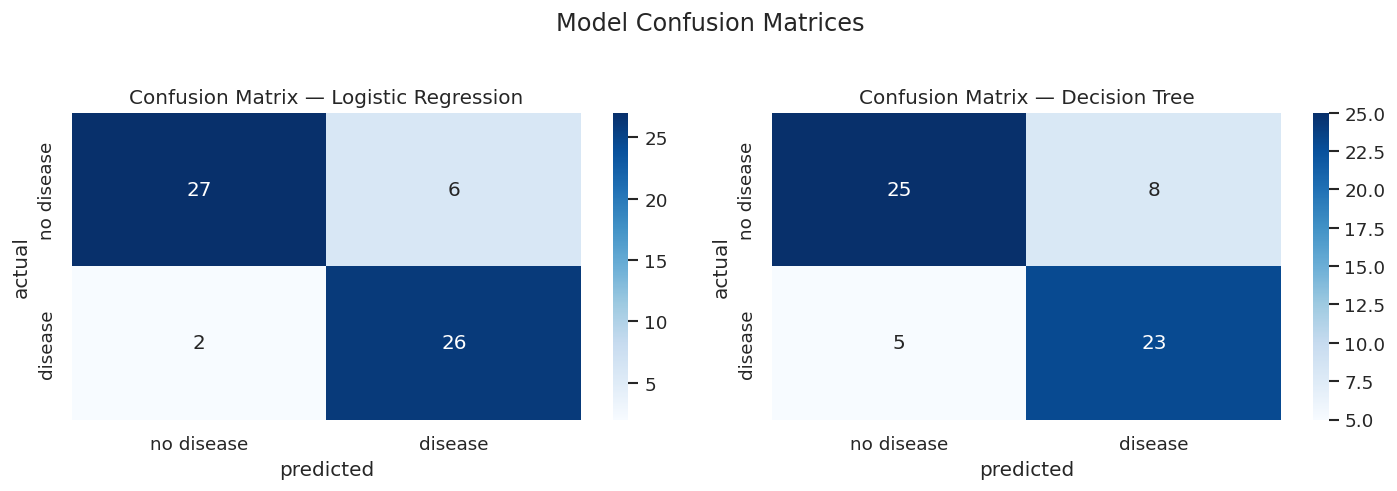

In [15]:
#  confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, preds, name in zip(
    axes,
    [lr_preds, dt_preds],
    ['Logistic Regression', 'Decision Tree']
):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['no disease', 'disease'],
                yticklabels=['no disease', 'disease'])
    ax.set_title(f'Confusion Matrix — {name}')
    ax.set_xlabel('predicted')
    ax.set_ylabel('actual')

plt.suptitle('Model Confusion Matrices', y=1.02) # Added a suptitle for clarity
plt.tight_layout()
plt.show()

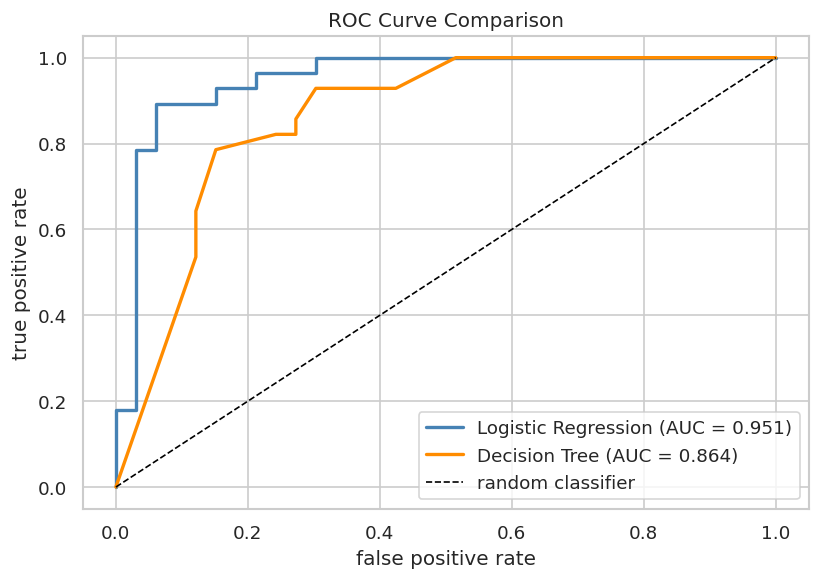

In [16]:
# roc curves
plt.figure(figsize=(7, 5))

for proba, name, color in [
    (lr_proba, 'Logistic Regression', 'steelblue'),
    (dt_proba, 'Decision Tree', 'darkorange')
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', color=color, linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='random classifier')
plt.xlabel('false positive rate')
plt.ylabel('true positive rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.tight_layout()
plt.show()

## 7. Feature Importance

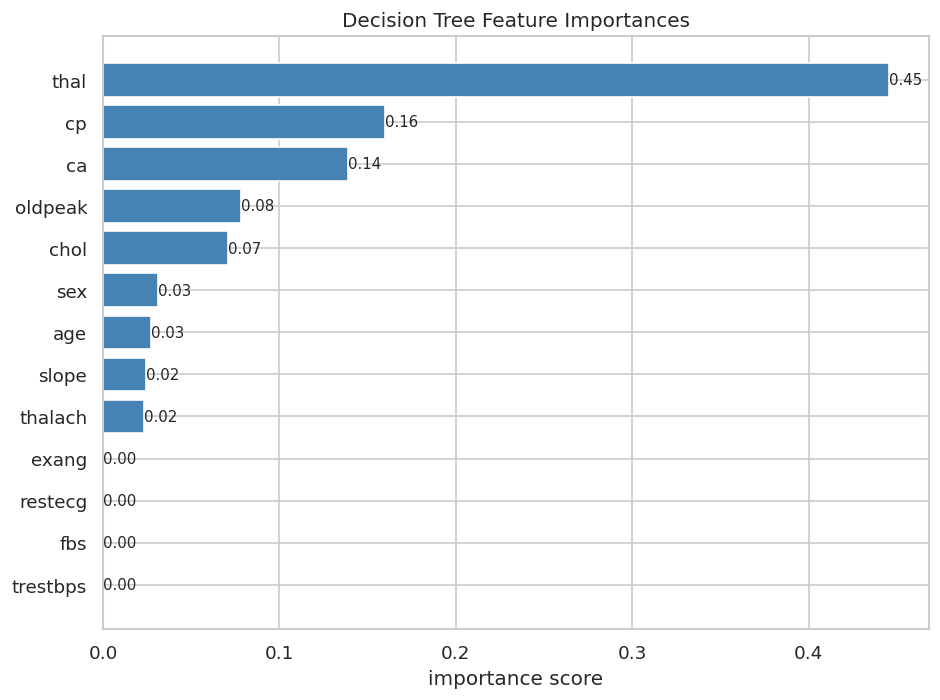

In [17]:
# decision tree feature importances
imp_df = pd.DataFrame({
    'feature': X.columns,
    'importance': dt.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(8, 6))
bars = plt.barh(imp_df['feature'], imp_df['importance'], color='steelblue')
plt.title('Decision Tree Feature Importances')
plt.xlabel('importance score')

# Add importance scores to the bars
for bar in bars:
    plt.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
             f'{bar.get_width():.2f}',
             va='center', ha='left', fontsize=9)

plt.tight_layout()
plt.show()

## Key Findings

- **Logistic Regression achieved ~85% accuracy** with strong ROC-AUC — great for a linear model on medical data.
- **Decision Tree** is slightly lower in accuracy but much more interpretable — each split is explainable to a doctor.
- **Top risk-increasing features:** `cp` (chest pain type), `thal` (thalassemia), `oldpeak` (ST depression), `ca` (major vessels)
- **Top risk-decreasing features:** `thalach` (max heart rate — lower max HR correlates with higher risk), `exang` (exercise-induced angina)
- The dataset is fairly balanced (~54% disease, ~46% no disease), so accuracy is a reliable metric here.

> In real clinical settings, we'd prioritize **recall** for the disease class (minimize false negatives — missing a sick patient is more dangerous than a false alarm).
